In [15]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.style.use('default')
sns.set_theme()

# 1. Load Dataset
from google.colab import drive
drive.mount('/content/drive')

df=pd.read_csv('/content/drive/MyDrive/AB_NYC_2019.csv')

df



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [16]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

# Distribution of Prices

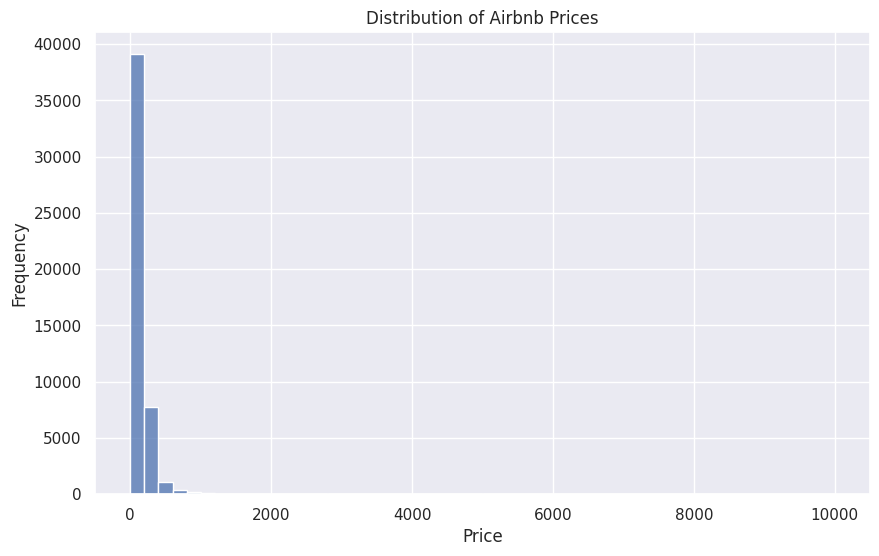

In [17]:
plt.figure(figsize=(10,6))

sns.histplot(df['price'], bins=50)

plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

# Listings by Neighborhood Group

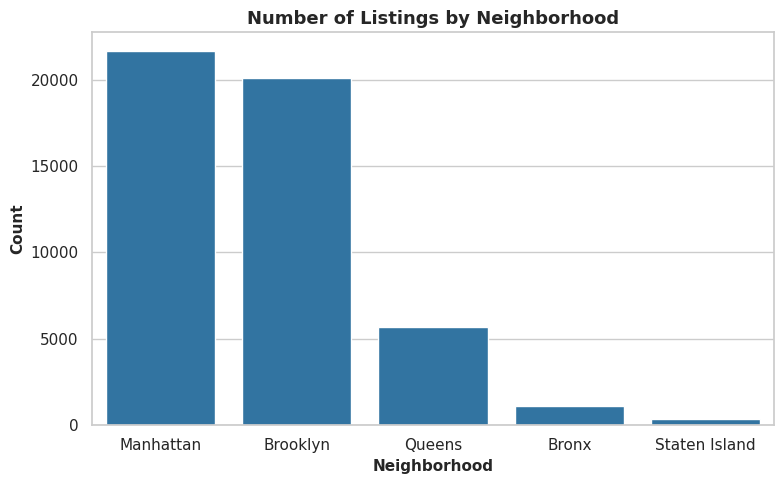

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='neighbourhood_group',
    order=df['neighbourhood_group'].value_counts().index
)

plt.title("Number of Listings by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Count")

plt.show()

# Room Type Distribution

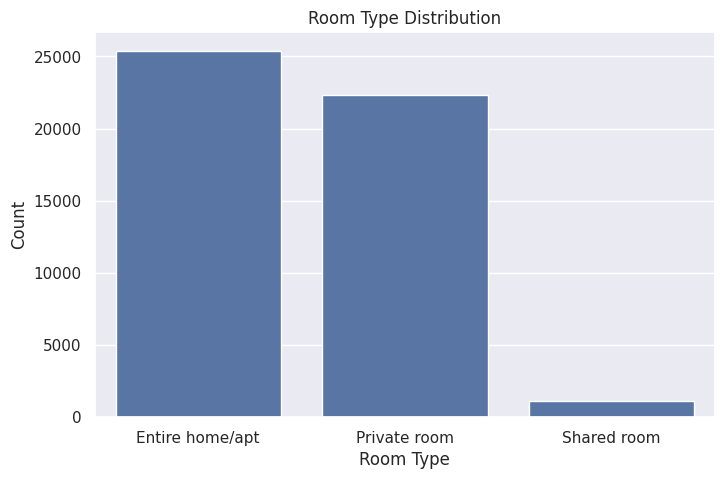

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='room_type',
    order=df['room_type'].value_counts().index
)

plt.title("Room Type Distribution")
plt.xlabel("Room Type")
plt.ylabel("Count")

plt.show()

# Average Price by Neighborhood

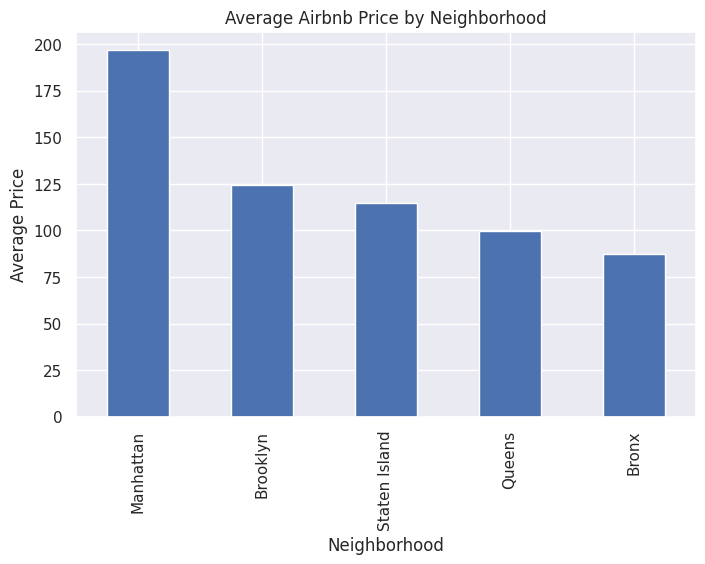

In [19]:
avg_price = df.groupby(
    'neighbourhood_group'
)['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))

avg_price.plot(kind='bar')

plt.title("Average Airbnb Price by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Average Price")

plt.show()

# Price Distribution by Room Type

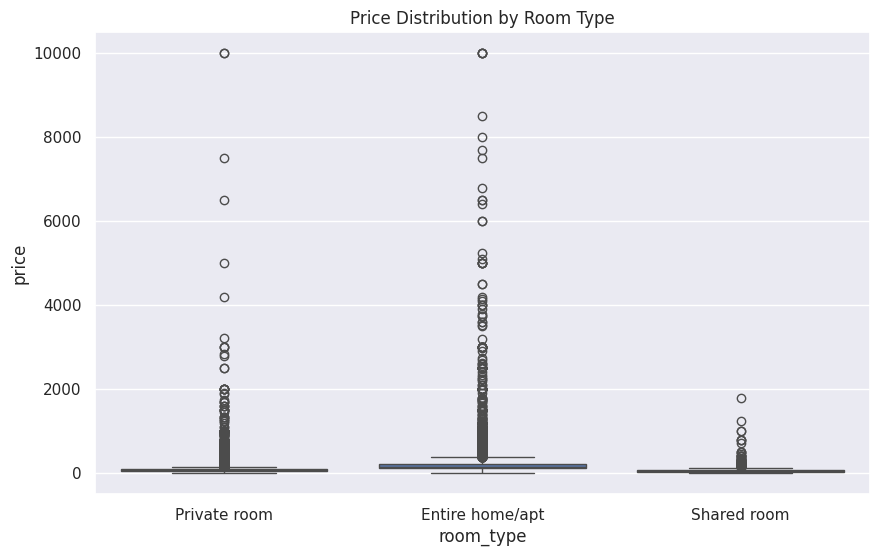

In [20]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='room_type',
    y='price'
)

plt.title("Price Distribution by Room Type")

plt.show()

# Top 10 Most Popular Neighborhoods

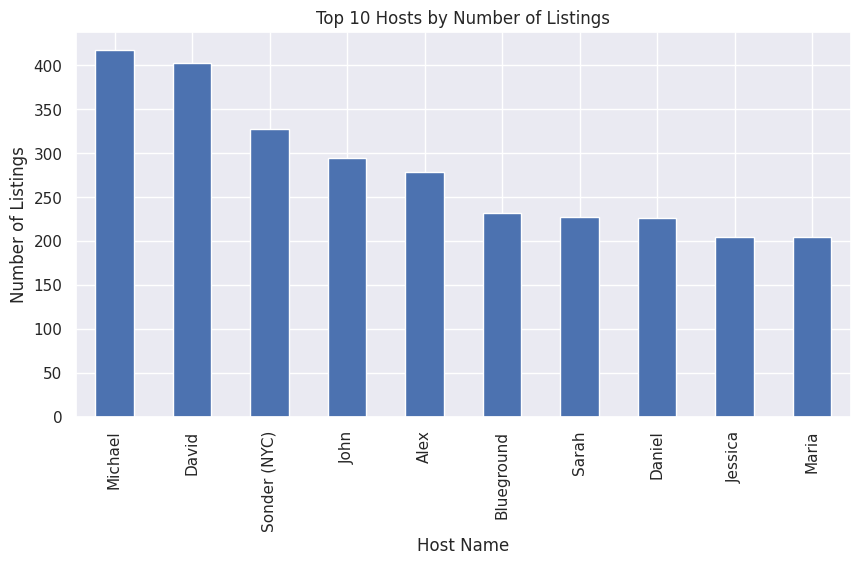

In [21]:
top_hosts = df['host_name'].value_counts().head(10)

plt.figure(figsize=(10,5))

top_hosts.plot(kind='bar')

plt.title("Top 10 Hosts by Number of Listings")
plt.xlabel("Host Name")
plt.ylabel("Number of Listings")

plt.show()

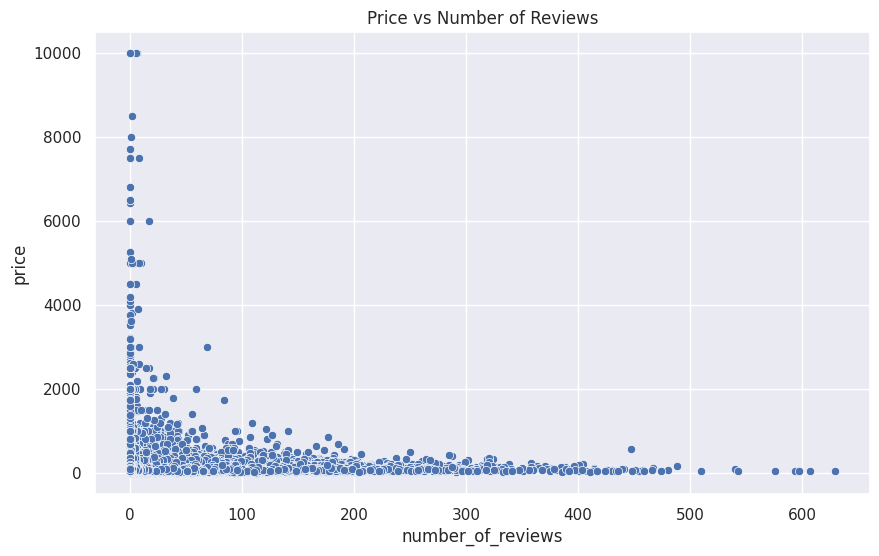

In [22]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='number_of_reviews',
    y='price'
)

plt.title("Price vs Number of Reviews")

plt.show()

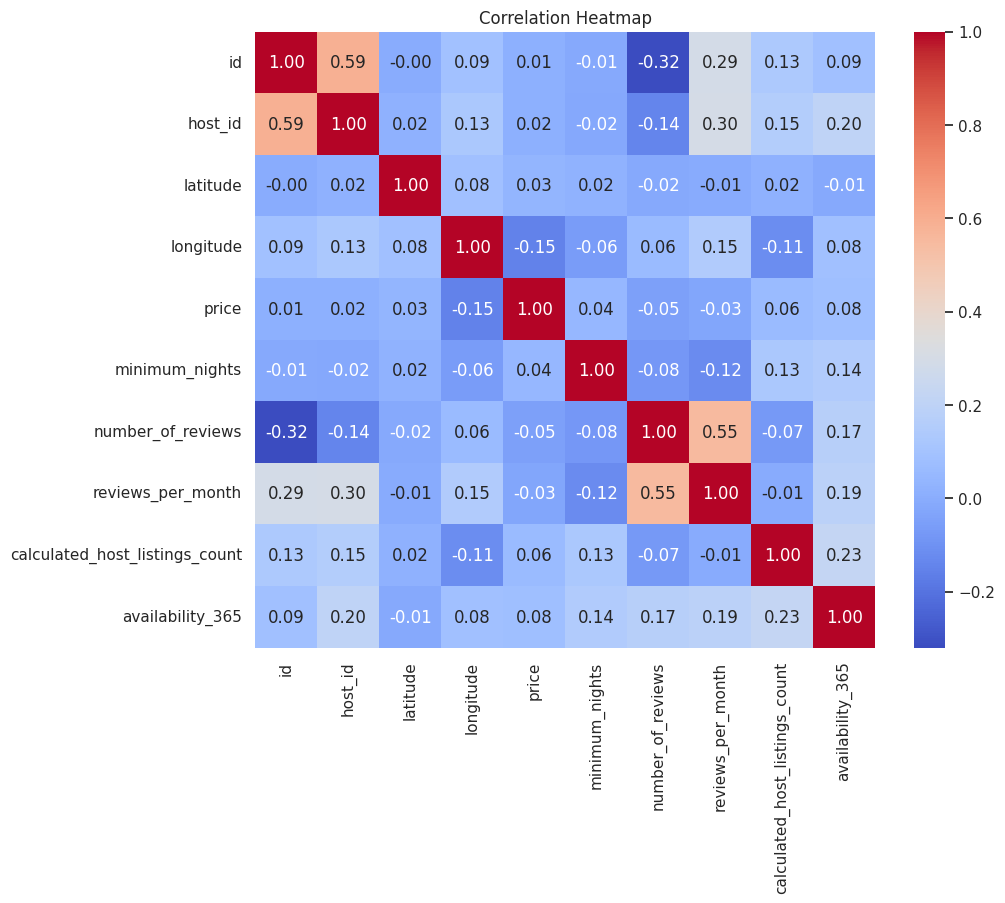

In [23]:
plt.figure(figsize=(10,8))

corr = df.select_dtypes(
    include=np.number
).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

# Top 10 Most Popular Neighborhoods

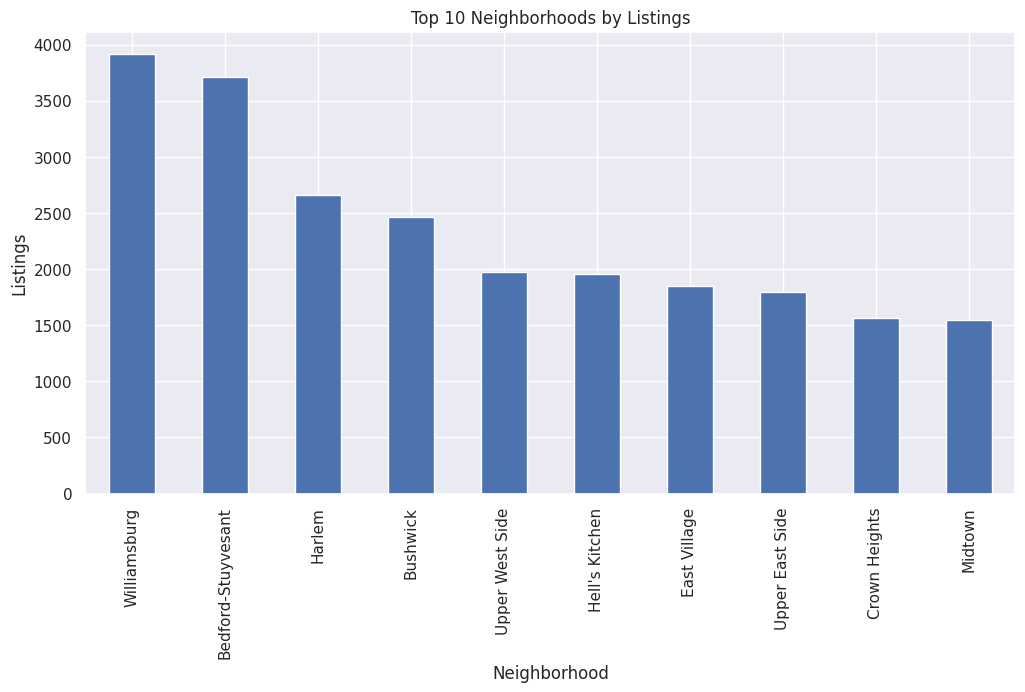

In [24]:
top_neighbourhoods = (
    df['neighbourhood']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

top_neighbourhoods.plot(kind='bar')

plt.title("Top 10 Neighborhoods by Listings")
plt.xlabel("Neighborhood")
plt.ylabel("Listings")

plt.show()

# Average Price by Room Type

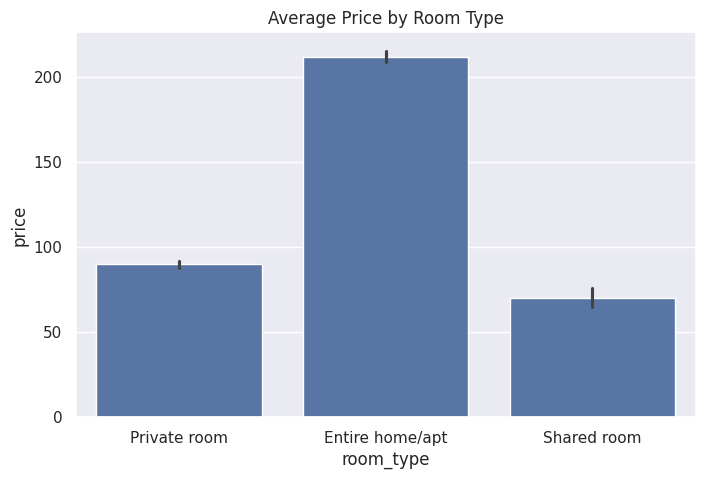

In [25]:

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='room_type',
    y='price',
    estimator=np.mean
)

plt.title("Average Price by Room Type")

plt.show()

# Pairplot (Advanced EDA)

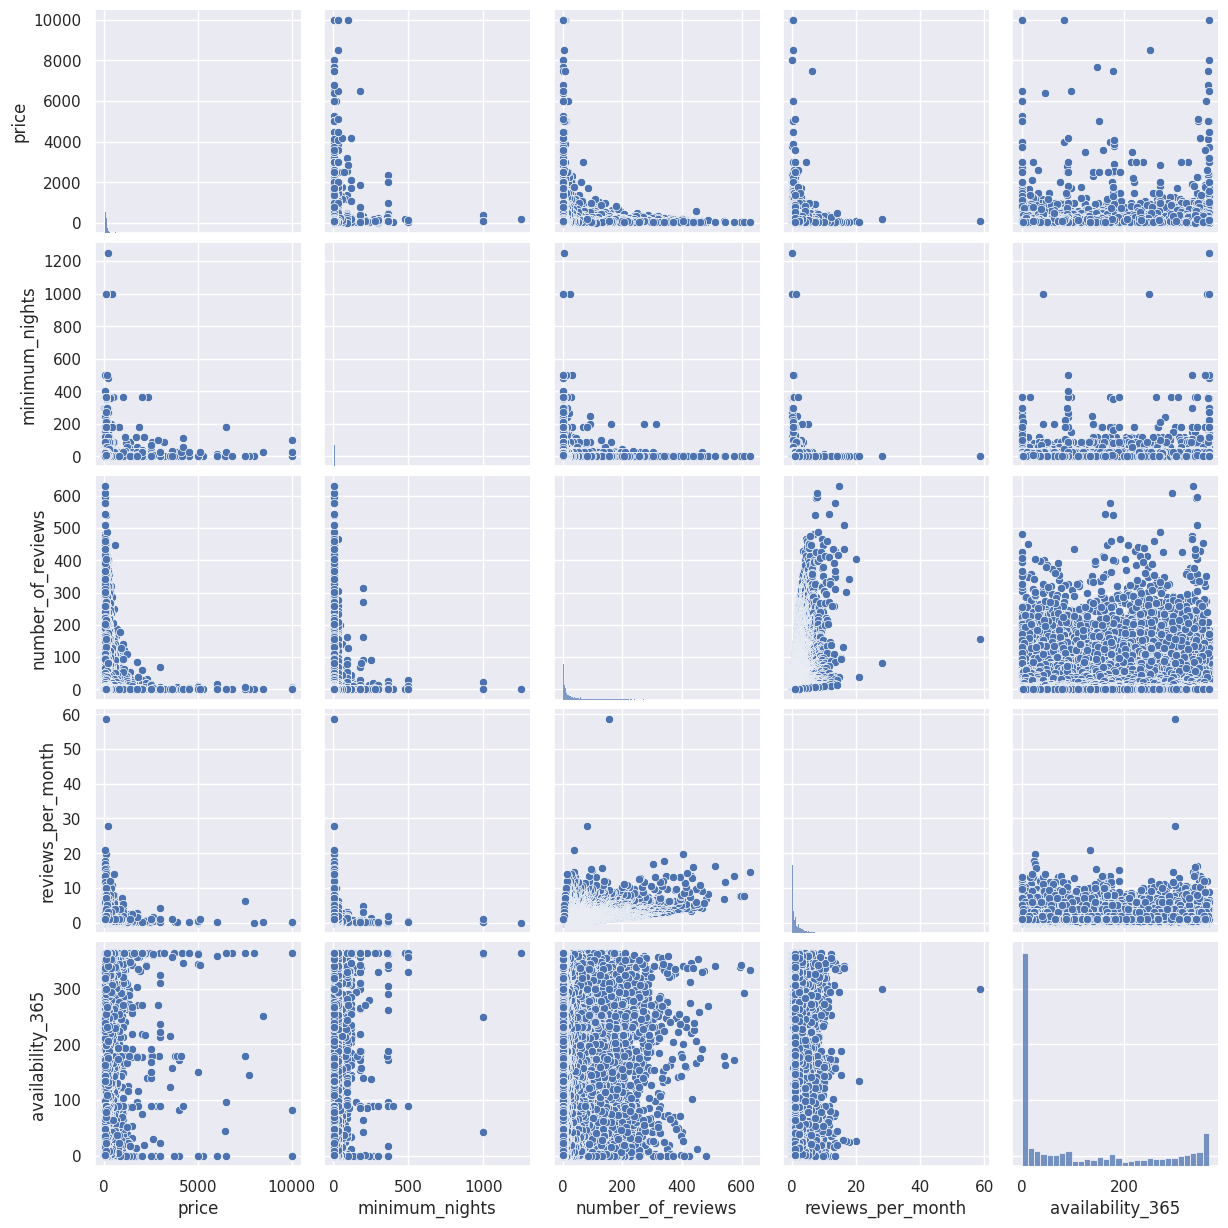

In [26]:

selected_cols = [
    'price',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'availability_365'
]

sns.pairplot(df[selected_cols])

plt.show()

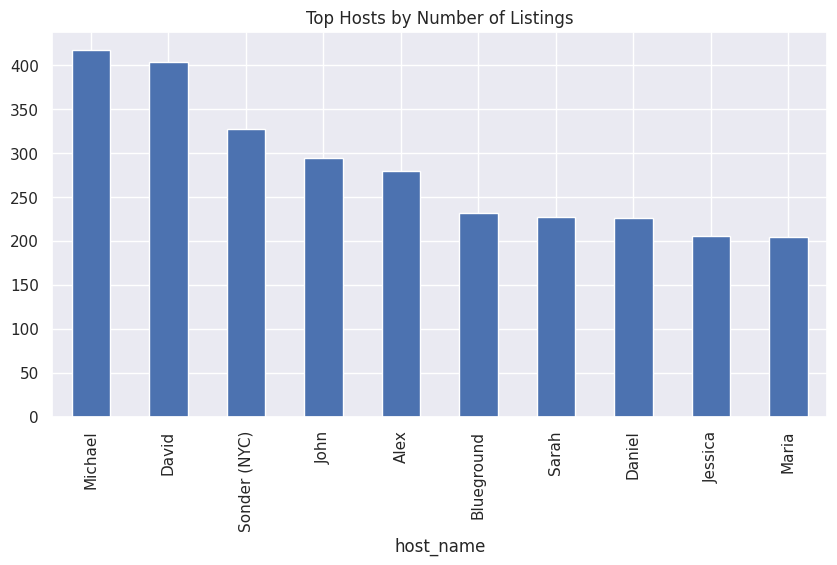

In [27]:
top_hosts = df['host_name'].value_counts().head(10)

top_hosts.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top Hosts by Number of Listings")
plt.show()


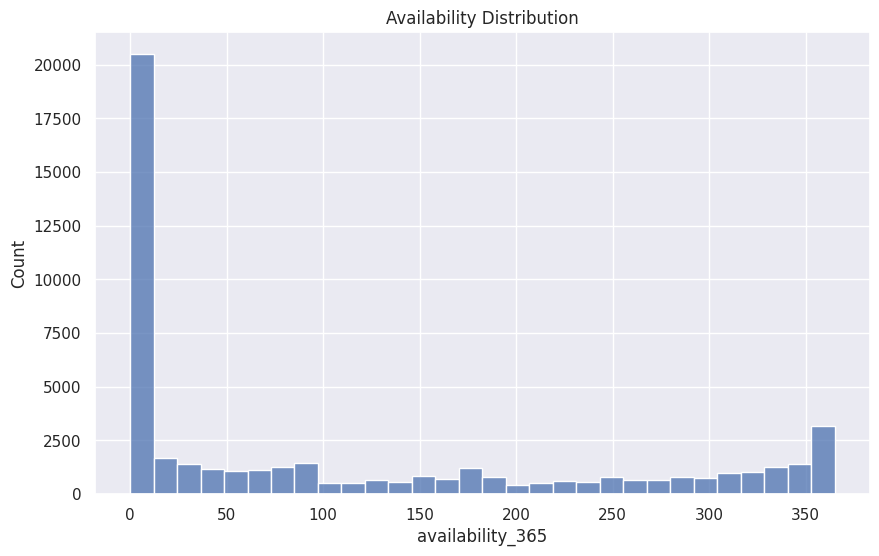

In [28]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['availability_365'],
    bins=30
)

plt.title("Availability Distribution")
plt.show()
